# PROJECT 2: Health Risk Predictor

## Notebook 1: Exploratory Data Analysis — Diabetes Dataset

**Author:** Niral Patel  
**Dataset:** CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015  
**Source:** [Kaggle — Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)  
**Records:** 253,680 patients × 22 features  
**Objective:** Predict diabetes risk using lifestyle, health, and demographic indicators  

---

In [2]:
# standard imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

#display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

#plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("all imports done")
print(f"pandas    :{pd.__version__}")
print(f"Numpy     :{np.__version__}")
print(f"Seaborn   :{sns.__version__}")

all imports done
pandas    :2.3.3
Numpy     :2.4.3
Seaborn   :0.13.2



## Load the Dataset and First Inspection


In [3]:
# Load the dataset
df = pd.read_csv('../notebook/data/diabetes_binary_health_indicators_BRFSS2015.csv')

## CDC BRFSS 2015 — COMPLETE DATA DICTIONARY

In [4]:
# -- Basic shape and info of the dataset
print('='*50)
print('DIABETES DATASET - FIRST LOOK')
print('='*50)
print(f"\n Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory Usage     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n-- Column Names and Data Types ---------------------------------------")
print(df.dtypes)

print("\n-- First 5 Rows ------------------------------------------------------")
df.head()

DIABETES DATASET - FIRST LOOK

 Shape         : 253,680 rows x 22 columns
Memory Usage     : 42.58 MB

-- Column Names and Data Types ---------------------------------------
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

-- First 5 Rows ------------------------------------------------------


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.00,1.00,1.00,1.00,40.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,5.00,18.00,15.00,1.00,0.00,9.00,4.00,3.00
1,0.00,0.00,0.00,0.00,25.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,3.00,0.00,0.00,0.00,0.00,7.00,6.00,1.00
2,0.00,1.00,1.00,1.00,28.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,5.00,30.00,30.00,1.00,0.00,9.00,4.00,8.00
3,0.00,1.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,11.00,3.00,6.00
4,0.00,1.00,1.00,1.00,24.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,3.00,0.00,0.00,0.00,11.00,5.00,4.00


---
## 📖 Data Dictionary

> **Source:** CDC BRFSS 2015 Annual telephone health survey of 400,000+ US adults

---

### 🎯 Target Variable

| Column | Values | Description |
|--------|--------|-------------|
| `Diabetes_binary` | 0 / 1 | 0 = No Diabetes, 1 = Diabetes (Type 1 or 2) |

---

### ✅ Binary Features (0 = No, 1 = Yes)

| Column | Description |
|--------|-------------|
| `HighBP` | Ever told you have high blood pressure? |
| `HighChol` | Ever told you have high cholesterol? |
| `CholCheck` | Had cholesterol check in past 5 years? |
| `Smoker` | Smoked at least 100 cigarettes in lifetime? |
| `Stroke` | Ever told you had a stroke? |
| `HeartDiseaseorAttack` | Coronary heart disease or heart attack ever? |
| `PhysActivity` | Physical activity in past 30 days? |
| `Fruits` | Consume fruit 1+ times per day? |
| `Veggies` | Consume vegetables 1+ times per day? |
| `HvyAlcoholConsump` | Heavy drinker? (Men >14/week, Women >7/week) |
| `AnyHealthcare` | Have any health care coverage or insurance? |
| `NoDocbcCost` | Could not see doctor in past year due to cost? |
| `DiffWalk` | Serious difficulty walking or climbing stairs? |
| `Sex` | 0 = Female, 1 = Male |

---

### 📊 Continuous Features

| Column | Range | Description |
|--------|-------|-------------|
| `BMI` | 12–98 | Body Mass Index (Underweight <18.5, Normal 18.5-24.9, Overweight 25-29.9, Obese 30+) |
| `MentHlth` | 0–30 | Days of poor mental health in past 30 days |
| `PhysHlth` | 0–30 | Days of poor physical health in past 30 days |

---

### 🔢 Categorical Features (Encoded as Numbers)

**GenHlth** — Self-rated General Health (1–5)

| Value | Meaning |
|-------|---------|
| 1 | Excellent |
| 2 | Very Good |
| 3 | Good |
| 4 | Fair |
| 5 | Poor |

**Age** — Age Group Categories (1–13)

| Value | Age Group | Value | Age Group |
|-------|-----------|-------|-----------|
| 1 | 18–24 | 8 | 55–59 |
| 2 | 25–29 | 9 | 60–64 |
| 3 | 30–34 | 10 | 65–69 |
| 4 | 35–39 | 11 | 70–74 |
| 5 | 40–44 | 12 | 75–79 |
| 6 | 45–49 | 13 | 80+ |
| 7 | 50–54 | | |

**Education** — Highest Grade Completed (1–6)

| Value | Meaning |
|-------|---------|
| 1 | Never attended / Kindergarten only |
| 2 | Grades 1–8 (Elementary) |
| 3 | Grades 9–11 (Some high school) |
| 4 | Grade 12 / GED (High school graduate) |
| 5 | College 1–3 years (Some college) |
| 6 | College 4+ years (College graduate) |

**Income** — Annual Household Income (1–8)

| Value | Income Bracket    |
|-------|-------------------|
| 1 | Less than $10,000 |
| 2 | $10,000 – $14,999 |
| 3 | $15,000 – $19,999 |
| 4 | $20,000 – $24,999 |
| 5 | $25,000 – $34,999 |
| 6 | $35,000 – $49,999 |
| 7 | $50,000 – $74,999 |
| 8 | $75,000 or more   |

---

### 🔧 Feature Engineering Opportunities (for later)

| New Feature | How | Why |
|-------------|-----|-----|
| `BMI_Category` | Group BMI into 4 buckets | More interpretable |
| `Age_Label` | Decode 1-13 to age ranges | Better visualization |
| `Age_RiskGroup` | Young / Middle / Senior | Clinical grouping |
| `Income_Label` | Decode 1-8 to brackets | Interpretable |
| `HealthScore` | MentHlth + PhysHlth combined | Composite health signal |
| `LifestyleScore` | PhysActivity + Fruits + Veggies | Healthy behavior score |
| `RiskFactorCount` | Sum all risk binary features | Total risk burden |

---

============================================================
### Target Distribution — Class Imbalance Analysis
============================================================

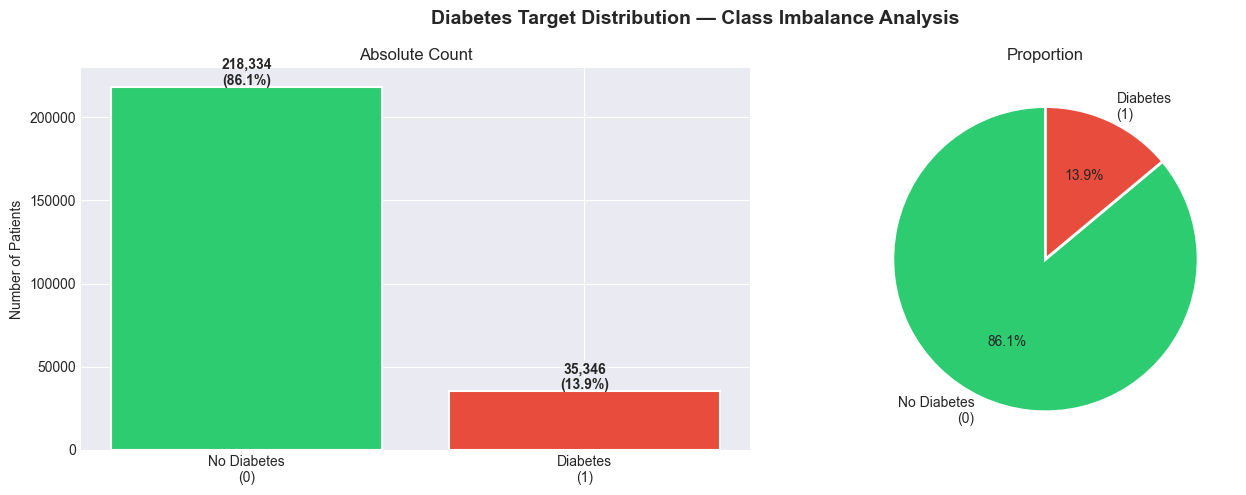


 CLASS IMBALANCE SUMMARY
 No Diabetes : 218,334 (86.1%)
 Diabetes    : 35,346 (13.9%)
 Imbalance   : 6.2:1 ratio

 WHY THIS MATTERS:
 A model predicting 'No Diabetes' for everyone
 would score 86.1% accuracy — but be useless!
 We need: Precision, Recall, F1, ROC-AUC, SMOTE


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diabetes Target Distribution — Class Imbalance Analysis',
             fontsize=14, fontweight='bold')

# ── Left: Count plot ───────────────────────────────────────
counts = df['Diabetes_binary'].value_counts()
labels = ['No Diabetes\n(0)', 'Diabetes\n(1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# ── Right: Pie chart ───────────────────────────────────────
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('../artifacts/diabetes_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print stats ────────────────────────────────────────────
print("\n CLASS IMBALANCE SUMMARY")
print("=" * 40)
print(f" No Diabetes : {counts[0.0]:,} ({counts[0.0]/len(df)*100:.1f}%)")
print(f" Diabetes    : {counts[1.0]:,} ({counts[1.0]/len(df)*100:.1f}%)")
print(f" Imbalance   : {counts[0.0]/counts[1.0]:.1f}:1 ratio")
print(f"\n WHY THIS MATTERS:")
print(f" A model predicting 'No Diabetes' for everyone")
print(f" would score {counts[0.0]/len(df)*100:.1f}% accuracy — but be useless!")
print(f" We need: Precision, Recall, F1, ROC-AUC, SMOTE")

===========================================================
## Missing Values Analysis
===========================================================

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("=" * 50)
print('Missing value analysis')
print("=" * 50)
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\n Total missing values: {missing.sum()}')
print(f'Dataset completeness: {100 - (missing.sum()/(df.shape[0]*df.shape[1])*100):.2f}%')

Missing value analysis
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total missing values: 0
Dataset completeness: 100.00%


## No Missing Values

CDC BRFSS dataset is PRE-CLEANED by the CDC government. This is a survey dataset — respondents answered every question. Real-world medical data (hospital records) will have 20-40% missing values. We'll see that when we get to the Kidney and Readmission datasets

In [7]:
for col in df.columns:
    print(f"{col}: {sorted(df[col].unique())}")

Diabetes_binary: [np.float64(0.0), np.float64(1.0)]
HighBP: [np.float64(0.0), np.float64(1.0)]
HighChol: [np.float64(0.0), np.float64(1.0)]
CholCheck: [np.float64(0.0), np.float64(1.0)]
BMI: [np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0)

==================================================
### Visualize Statistical Summary
==================================================

In [6]:
print("=" * 60)
print(" STATISTICAL SUMMARY — ALL 22 FEATURES")
print("=" * 60)

stats = df.describe().T
stats['range'] = stats['max'] - stats['min']
stats['cv%'] = (stats['std'] / stats['mean'] * 100).round(1)

print(stats[['mean', 'std', 'min', 'max', 'range', 'cv%']].round(2))

print("\n\n KEY OBSERVATIONS:")
print("-" * 60)

# Binary vs continuous features
binary_cols = [col for col in df.columns 
               if df[col].nunique() == 2]
continuous_cols = [col for col in df.columns 
                   if df[col].nunique() > 2]

print(f"\n Binary features  ({len(binary_cols)}): {binary_cols}")
print(f"\n Continuous features ({len(continuous_cols)}): {continuous_cols}")

# BMI range check
print(f"\n BMI range   : {df['BMI'].min():.0f} — {df['BMI'].max():.0f}")
print(f" BMI mean    : {df['BMI'].mean():.1f}")
print(f" Age range   : {df['Age'].min():.0f} — {df['Age'].max():.0f}")
print(f" Age note    : Age is CATEGORICAL here (1=18-24, 13=80+)")
print(f"\n MentHlth range : {df['MentHlth'].min():.0f} — {df['MentHlth'].max():.0f}")
print(f" PhysHlth range : {df['PhysHlth'].min():.0f} — {df['PhysHlth'].max():.0f}")
print(f" Note: These = number of bad health days in past 30 days")

 STATISTICAL SUMMARY — ALL 22 FEATURES
                      mean  std   min   max  range    cv%
Diabetes_binary       0.14 0.35  0.00  1.00   1.00 248.50
HighBP                0.43 0.49  0.00  1.00   1.00 115.40
HighChol              0.42 0.49  0.00  1.00   1.00 116.50
CholCheck             0.96 0.19  0.00  1.00   1.00  19.70
BMI                  28.38 6.61 12.00 98.00  86.00  23.30
Smoker                0.44 0.50  0.00  1.00   1.00 112.10
Stroke                0.04 0.20  0.00  1.00   1.00 486.30
HeartDiseaseorAttack  0.09 0.29  0.00  1.00   1.00 310.10
PhysActivity          0.76 0.43  0.00  1.00   1.00  56.70
Fruits                0.63 0.48  0.00  1.00   1.00  75.90
Veggies               0.81 0.39  0.00  1.00   1.00  48.20
HvyAlcoholConsump     0.06 0.23  0.00  1.00   1.00 409.80
AnyHealthcare         0.95 0.22  0.00  1.00   1.00  22.70
NoDocbcCost           0.08 0.28  0.00  1.00   1.00 329.80
GenHlth               2.51 1.07  1.00  5.00   4.00  42.50
MentHlth              3.18 7.41  

### Key Findings
BMI min = 12   ← OUTLIER ALERT (BMI 12 is near impossible, starvation level)
BMI max = 98   ← OUTLIER ALERT (extremely rare, needs investigation)
BMI mean = 28.4 ← "Overweight" range, realistic for US population

Age 1–13       ← Categorical buckets, NOT real age numbers
               1=18-24, 2=25-29...13=80+ (important for feature engineering)

MentHlth/PhysHlth 0-30 ← Days in past 30 days (makes sense)

Stroke cv% = 486%  ← Extremely rare event (4% prevalence) — very skewed
HeartDisease cv% = 310% ← Same pattern

## Distribution Analysis - Continuous Features

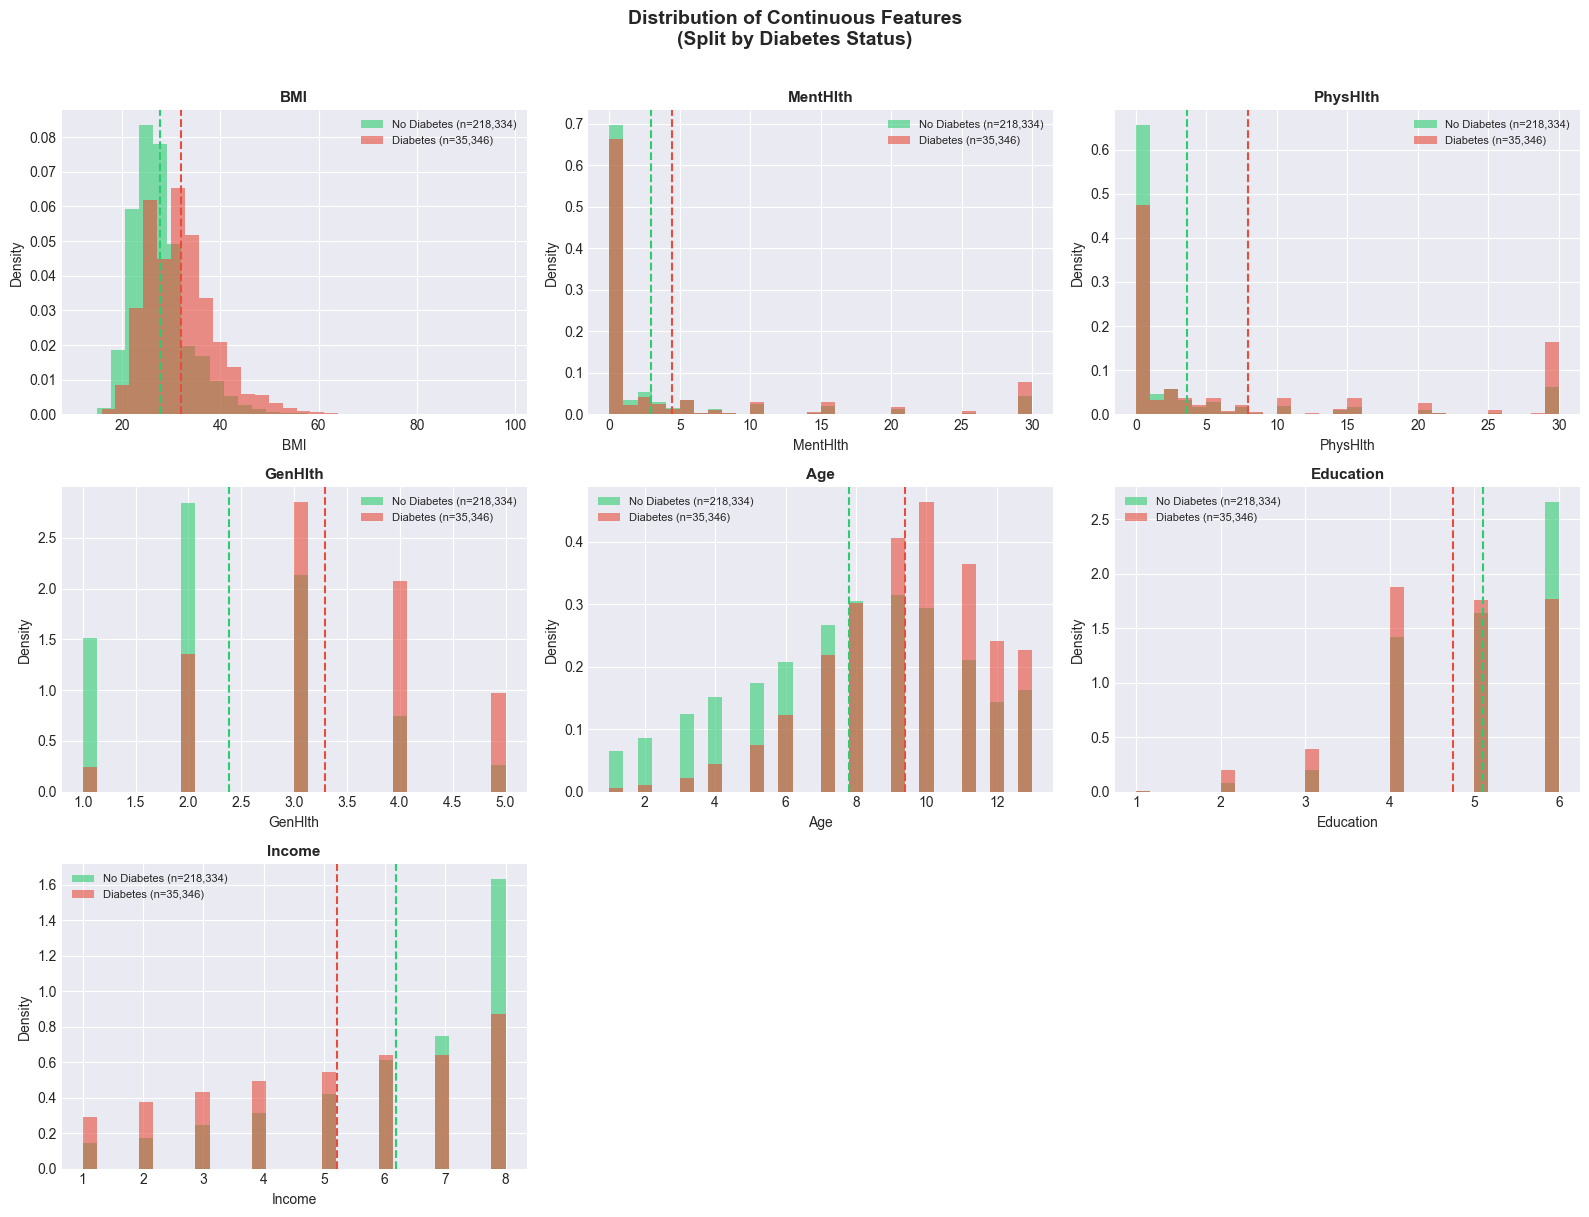

 MEAN VALUES BY TARGET CLASS
           No Diabetes  Diabetes
BMI              27.81     31.94
MentHlth          2.98      4.46
PhysHlth          3.64      7.95
GenHlth           2.39      3.29
Age               7.81      9.38
Education         5.10      4.75
Income            6.19      5.21


 BMI OUTLIER CHECK:
 Patients with BMI < 15  : 68
 Patients with BMI > 60  : 805
 Patients with BMI 18-40 : 240,877 (95.0%)


In [7]:
# ============================================================
# CELL 6: Distribution Analysis — Continuous Features
# ============================================================

continuous = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 
              'Education', 'Income']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution of Continuous Features\n(Split by Diabetes Status)',
             fontsize=14, fontweight='bold', y=1.01)

axes = axes.flatten()

colors = {0.0: '#2ecc71', 1.0: '#e74c3c'}
labels = {0.0: 'No Diabetes', 1.0: 'Diabetes'}

for idx, col in enumerate(continuous):
    ax = axes[idx]
    
    for target_val in [0.0, 1.0]:
        subset = df[df['Diabetes_binary'] == target_val][col]
        ax.hist(subset, bins=30, alpha=0.6,
                color=colors[target_val],
                label=f"{labels[target_val]} (n={len(subset):,})",
                density=True, edgecolor='none')
    
    ax.set_title(f'{col}', fontweight='bold', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    
    # Add mean lines
    for target_val in [0.0, 1.0]:
        mean_val = df[df['Diabetes_binary'] == target_val][col].mean()
        ax.axvline(mean_val, color=colors[target_val],
                   linestyle='--', linewidth=1.5)

# Hide empty subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.tight_layout()
plt.savefig('../artifacts/diabetes_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key Stats per feature by target ───────────────────────
print("=" * 65)
print(" MEAN VALUES BY TARGET CLASS")
print("=" * 65)
means = df.groupby('Diabetes_binary')[continuous].mean().round(2)
means.index = ['No Diabetes', 'Diabetes']
print(means.T.to_string())

print("\n\n BMI OUTLIER CHECK:")
print(f" Patients with BMI < 15  : {(df['BMI'] < 15).sum():,}")
print(f" Patients with BMI > 60  : {(df['BMI'] > 60).sum():,}")
print(f" Patients with BMI 18-40 : {((df['BMI']>=18)&(df['BMI']<=40)).sum():,} ({((df['BMI']>=18)&(df['BMI']<=40)).sum()/len(df)*100:.1f}%)")

---
## 📊 Cell 6 — Key Observations: Distribution Analysis

### BMI
- Diabetic patients have a mean BMI of **31.94 (Obese)** vs **27.81 (Overweight)** for non-diabetics
- Distribution shifts clearly **rightward** for diabetic patients
- **805 patients** have BMI > 60 (extreme outliers — will apply IQR capping in preprocessing)
- **95% of patients** fall in the 18–40 BMI range

### Mental & Physical Health
- Diabetic patients report **+4.3 more bad physical health days** per month
- Spike at 30 days in diabetic group = chronic daily suffering
- Both features show **zero-inflated distributions** — most people report 0 bad days

### General Health (GenHlth)
- Clear separation between groups (2.39 vs 3.29)
- Self-rated health is a **strong predictor** of diabetes diagnosis
- Will be an important feature in the model

### Age
- Diabetes prevalence increases with age — peaks at group 9–10 (60–69 years)
- Younger age groups (1–5) are predominantly non-diabetic
- Age is one of the **strongest demographic predictors**

### Socioeconomic Factors (Education + Income)
- Lower education and lower income both correlate with higher diabetes risk
- These are **social determinants of health** — not direct medical causes
- Will investigate interaction effects between Income and Healthcare access

### ⚠️ Feature Engineering Planned
- `BMI_Category`: Underweight / Normal / Overweight / Obese
- `Age_Label`: Decode 1–13 to actual age ranges
- `HealthScore`: Composite of MentHlth + PhysHlth
- `SocioRiskScore`: Composite of Income + Education
---

 BINARY FEATURE PREVALENCE BY DIABETES STATUS
                      No Diabetes %  Diabetes %  Difference
HighBP                        37.70       75.30       37.60
HighChol                      38.40       67.00       28.60
DiffWalk                      13.50       37.10       23.60
HeartDiseaseorAttack           7.30       22.30       15.00
Smoker                        43.10       51.80        8.70
Stroke                         3.20        9.20        6.00
Sex                           43.40       47.90        4.50
CholCheck                     95.80       99.30        3.50
NoDocbcCost                    8.10       10.60        2.50
AnyHealthcare                 95.00       96.00        1.00
HvyAlcoholConsump              6.10        2.40       -3.80
Fruits                        64.20       58.50       -5.70
Veggies                       82.00       75.60       -6.40
PhysActivity                  77.70       63.10      -14.60


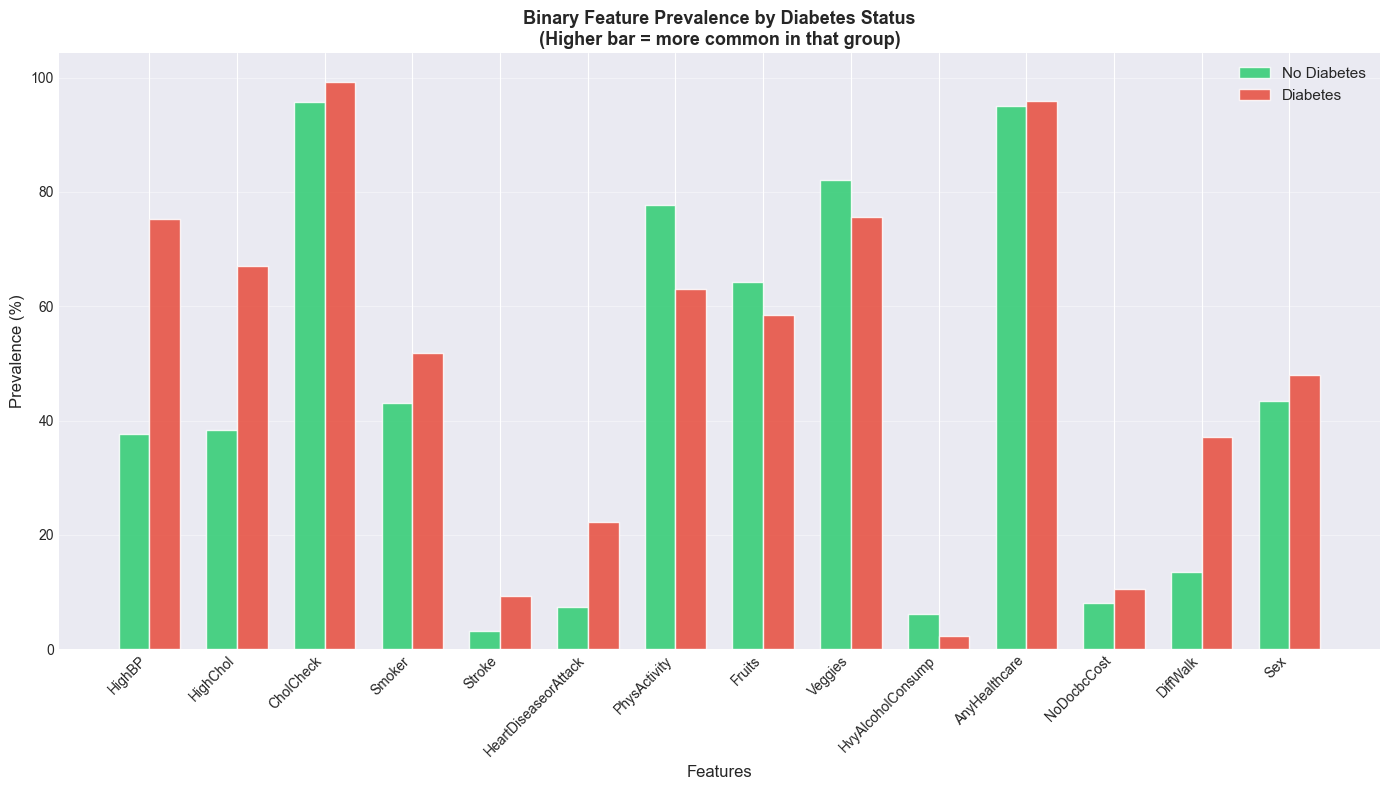

In [8]:
# ============================================================
# CELL 7: Binary Features — Prevalence by Diabetes Status
# ============================================================

binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
               'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
               'Fruits', 'Veggies', 'HvyAlcoholConsump',
               'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

# Calculate prevalence % for each group
prev_no_diabetes = df[df['Diabetes_binary']==0][binary_cols].mean() * 100
prev_diabetes    = df[df['Diabetes_binary']==1][binary_cols].mean() * 100
diff             = prev_diabetes - prev_no_diabetes

prevalence_df = pd.DataFrame({
    'No Diabetes %': prev_no_diabetes.round(1),
    'Diabetes %'   : prev_diabetes.round(1),
    'Difference'   : diff.round(1)
}).sort_values('Difference', ascending=False)

print("=" * 60)
print(" BINARY FEATURE PREVALENCE BY DIABETES STATUS")
print("=" * 60)
print(prevalence_df.to_string())

# ── Visualization ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(binary_cols))
width = 0.35

bars1 = ax.bar(x - width/2, prev_no_diabetes,
               width, label='No Diabetes',
               color='#2ecc71', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, prev_diabetes,
               width, label='Diabetes',
               color='#e74c3c', alpha=0.85, edgecolor='white')

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Prevalence (%)', fontsize=12)
ax.set_title('Binary Feature Prevalence by Diabetes Status\n'
             '(Higher bar = more common in that group)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(binary_cols, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../artifacts/diabetes_binary_prevalence.png',
            dpi=150, bbox_inches='tight')
plt.show()


---
## 📊 Cell 7 — Key Observations: Binary Feature Analysis

### 🔴 Top Risk Factors (Strongest Positive Correlation with Diabetes)

| Feature | No Diabetes | Diabetes | Difference | Clinical Meaning |
|---------|------------|----------|------------|-----------------|
| `HighBP` | 37.7% | 75.3% | **+37.6%** | #1 predictor — hypertension drives insulin resistance |
| `HighChol` | 38.4% | 67.0% | **+28.6%** | Metabolic syndrome marker |
| `DiffWalk` | 13.5% | 37.1% | **+23.6%** | Diabetic neuropathy / obesity consequence |
| `HeartDiseaseorAttack` | 7.3% | 22.3% | **+15.0%** | Metabolic syndrome — diseases cluster together |

### 🟢 Protective Factors (Higher in Non-Diabetics)

| Feature | Difference | Clinical Meaning |
|---------|------------|-----------------|
| `PhysActivity` | -14.6% | Exercise improves insulin sensitivity |
| `Veggies` | -6.4% | Fiber and nutrients regulate blood sugar |
| `Fruits` | -5.7% | Healthy diet = lower obesity = lower diabetes risk |

### 💡 Surprising / Counterintuitive Findings
- **`HvyAlcoholConsump`** is slightly MORE common in non-diabetics — likely age confounding (heavy drinkers skew younger)
- **`AnyHealthcare`** shows almost no difference (+1%) — having insurance doesn't prevent diabetes; it may increase **detection rates**
- **`CholCheck`** (95% vs 99%) — near-universal, very low discriminative power → **candidate for removal during feature selection**

### ⚠️ Modeling Implications
- `HighBP` + `HighChol` + `DiffWalk` will likely be **top 3 features** in our model
- `CholCheck` and `AnyHealthcare` may be **dropped** during feature selection
- Interaction feature: `HighBP × HighChol` could capture metabolic syndrome patients
---

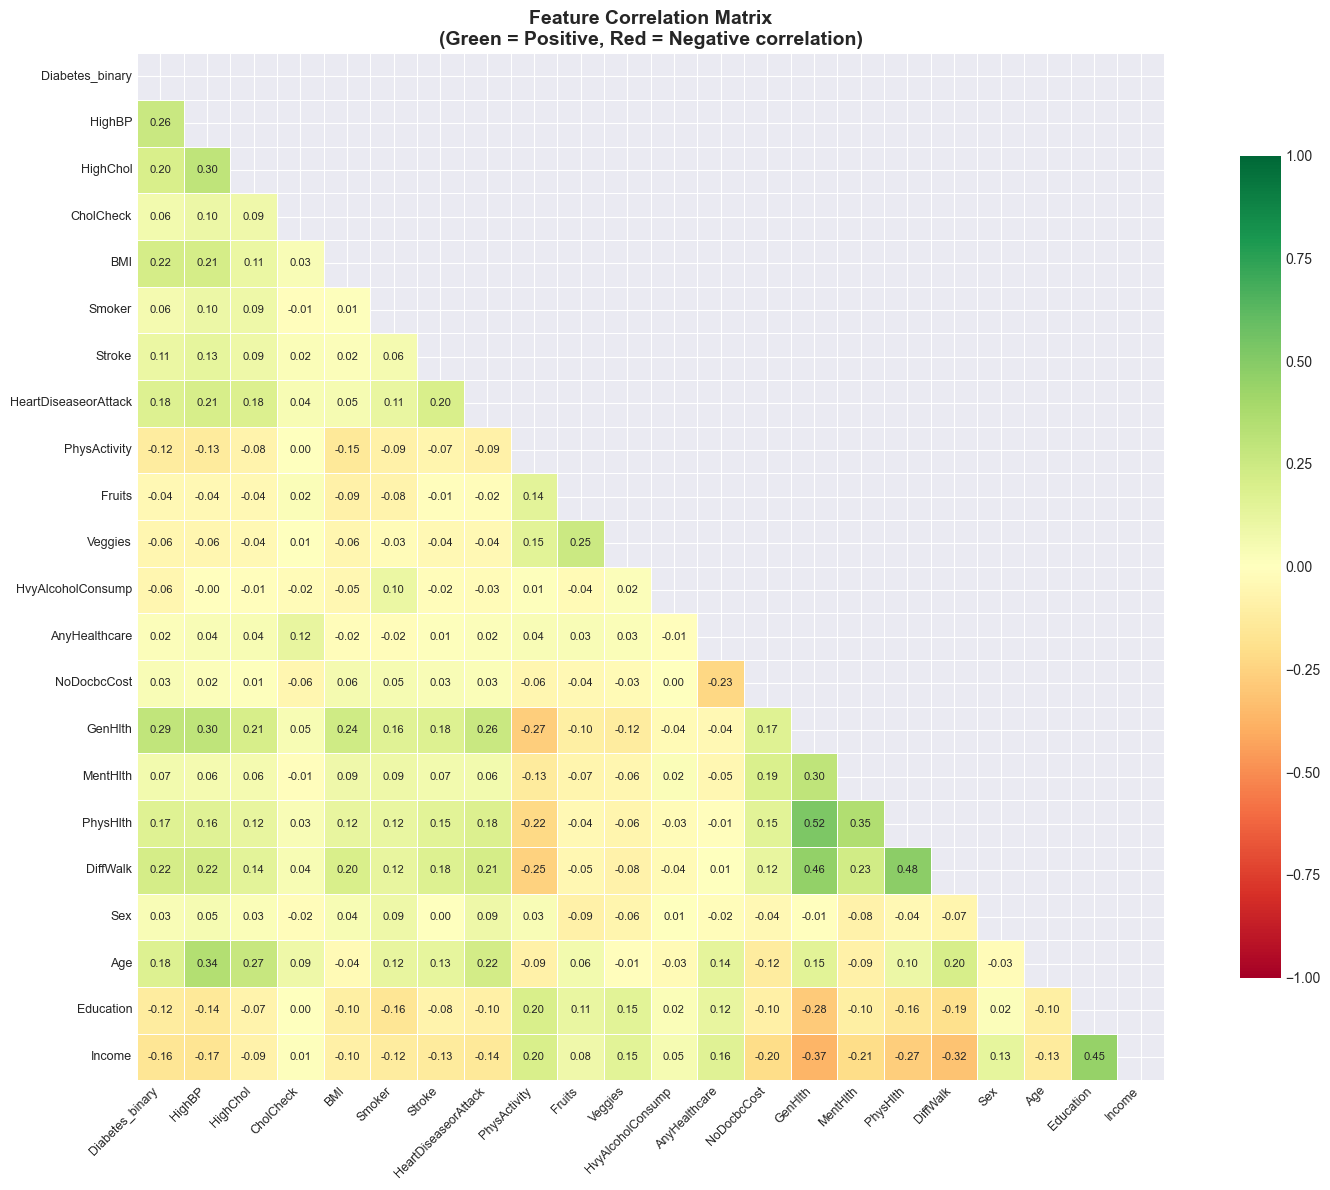

 FEATURE CORRELATION WITH TARGET (Diabetes_binary)
  GenHlth                   +0.294  ███████████
  HighBP                    +0.263  ██████████
  DiffWalk                  +0.218  ████████
  BMI                       +0.217  ████████
  HighChol                  +0.200  ████████
  Age                       +0.177  ███████
  HeartDiseaseorAttack      +0.177  ███████
  PhysHlth                  +0.171  ██████
  Income                    -0.164  ██████
  Education                 -0.124  ████
  PhysActivity              -0.118  ████
  Stroke                    +0.106  ████
  MentHlth                  +0.069  ██
  CholCheck                 +0.065  ██
  Smoker                    +0.061  ██
  HvyAlcoholConsump         -0.057  ██
  Veggies                   -0.057  ██
  Fruits                    -0.041  █
  NoDocbcCost               +0.031  █
  Sex                       +0.031  █
  AnyHealthcare             +0.016  

 Top 5 predictors: ['GenHlth', 'HighBP', 'DiffWalk', 'BMI', 'HighChol']
 We

In [10]:
# ============================================================
# CELL 8: Correlation Analysis — Heatmap
# ============================================================

plt.figure(figsize=(16, 12))

corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})

plt.title('Feature Correlation Matrix\n'
          '(Green = Positive, Red = Negative correlation)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../artifacts/diabetes_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top correlations WITH target only ─────────────────────
print("=" * 55)
print(" FEATURE CORRELATION WITH TARGET (Diabetes_binary)")
print("=" * 55)
target_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary')
target_corr = target_corr.abs().sort_values(ascending=False)

for feat, corr_val in target_corr.items():
    bar = '█' * int(corr_val * 40)
    direction = corr_matrix['Diabetes_binary'][feat]
    sign = '+' if direction > 0 else '-'
    print(f"  {feat:<25} {sign}{corr_val:.3f}  {bar}")

print(f"\n Top 5 predictors: {list(target_corr.head(5).index)}")
print(f" Weakest features: {list(target_corr.tail(3).index)}")

---
## 📊 Cell 8 — Key Observations: Correlation Analysis

### 🎯 Top 5 Predictors of Diabetes
| Rank | Feature | Correlation | Meaning |
|------|---------|-------------|---------|
| 1 | `GenHlth` | +0.294 | Self-rated health — patients feel worse before diagnosis |
| 2 | `HighBP` | +0.263 | Hypertension is #1 medical comorbidity |
| 3 | `DiffWalk` | +0.218 | Physical disability from diabetes complications |
| 4 | `BMI` | +0.217 | Obesity drives insulin resistance |
| 5 | `HighChol` | +0.200 | Metabolic syndrome marker |

### ❌ Features to Drop (Near-Zero Signal)
| Feature | Correlation | Reason |
|---------|-------------|--------|
| `AnyHealthcare` | +0.016 | No discriminative power |
| `Sex` | +0.031 | Very weak signal |
| `NoDocbcCost` | +0.031 | Very weak signal |
| `CholCheck` | +0.065 | 95%+ universal — no separation |

### ⚠️ Multicollinearity Alert
| Feature Pair | Correlation | Action |
|-------------|-------------|--------|
| `PhysHlth` ↔ `MentHlth` | 0.35 | Combine → `HealthScore` |
| `Income` ↔ `Education` | 0.45 | Combine → `SocioScore` |
| `DiffWalk` ↔ `PhysHlth` | 0.48 | Keep DiffWalk (stronger signal) |

### 📋 Final Feature Engineering Plan
```
DROP   : AnyHealthcare, Sex, NoDocbcCost, CholCheck
CREATE : BMI_Category (4 groups)
CREATE : HealthScore = MentHlth + PhysHlth (then drop originals)
CREATE : SocioScore = Income + Education (then drop originals)  
CREATE : RiskScore = HighBP + HighChol + Stroke + HeartDiseaseorAttack
KEEP   : All remaining features
```
---

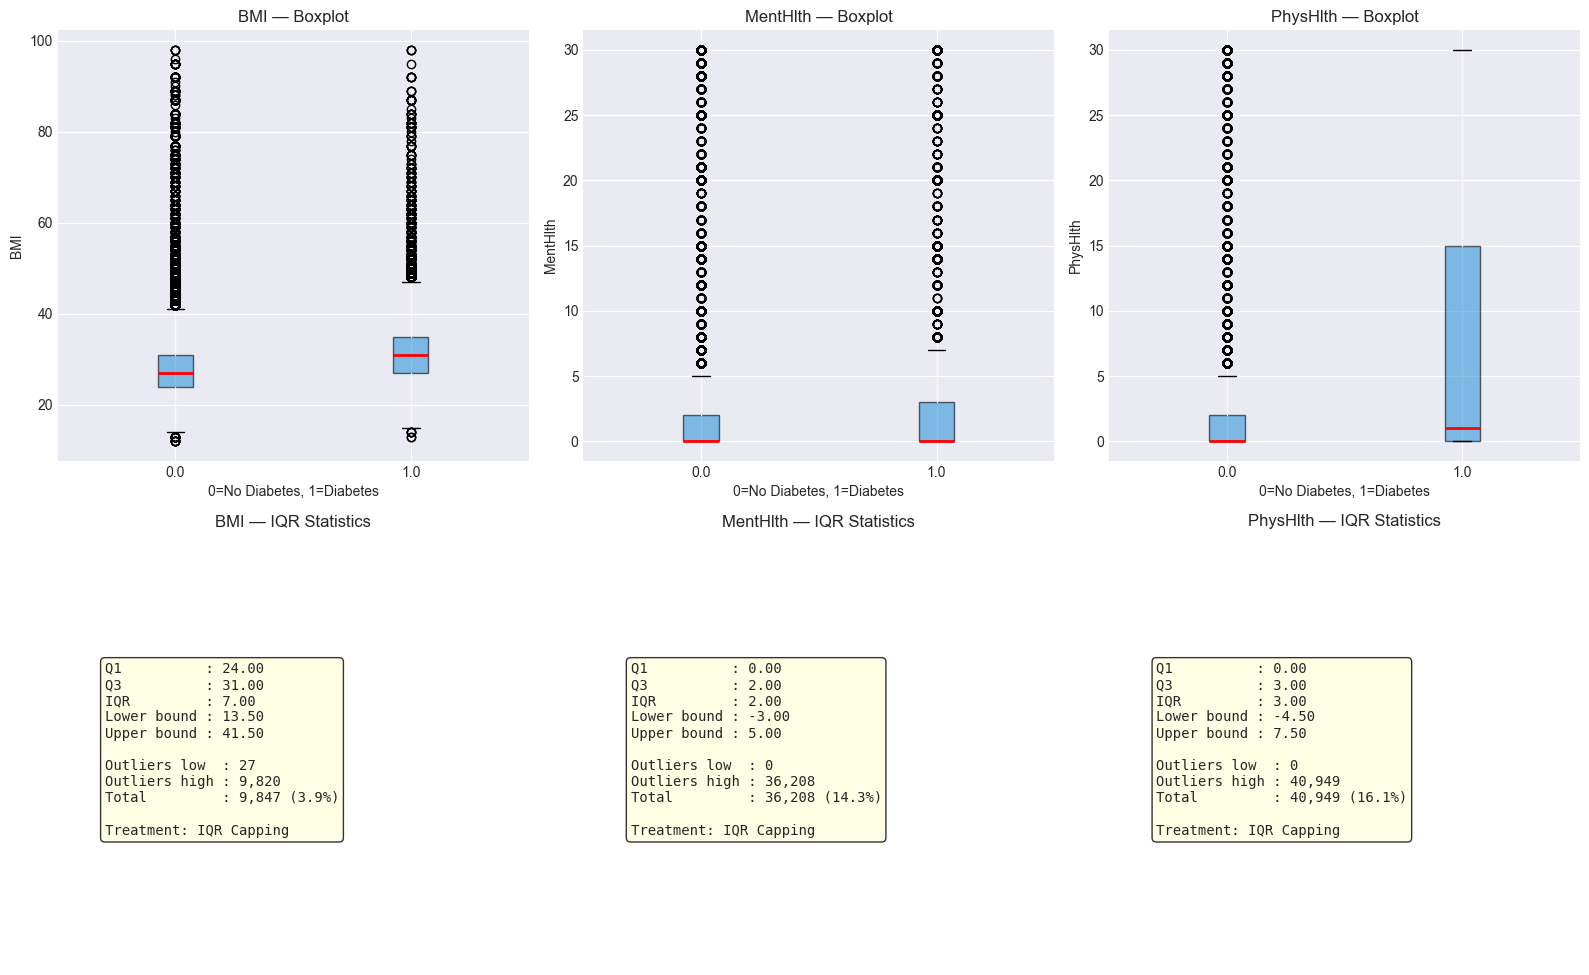

 OUTLIER TREATMENT PLAN

  BMI
    Bounds  : [13.5, 41.5]
    Outliers: 9,847 (3.9%)
    Action  : CLIP to IQR bounds

  MentHlth
    Bounds  : [-3.0, 5.0]
    Outliers: 36,208 (14.3%)
    Action  : CLIP to IQR bounds

  PhysHlth
    Bounds  : [-4.5, 7.5]
    Outliers: 40,949 (16.1%)
    Action  : CLIP to IQR bounds


In [11]:
# ============================================================
# CELL 9: Outlier Detection and Treatment Plan
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Outlier Analysis — Continuous Features',
             fontsize=14, fontweight='bold')

continuous_outlier = ['BMI', 'MentHlth', 'PhysHlth']

for idx, col in enumerate(continuous_outlier):
    
    # ── Box plot ───────────────────────────────────────────
    ax_box = axes[0, idx]
    df.boxplot(column=col, by='Diabetes_binary', ax=ax_box,
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax_box.set_title(f'{col} — Box Plot by Diabetes Status')
    ax_box.set_xlabel('0=No Diabetes, 1=Diabetes')
    ax_box.set_ylabel(col)
    plt.sca(ax_box)
    plt.title(f'{col} — Boxplot')

    # ── IQR calculation ────────────────────────────────────
    ax_info = axes[1, idx]
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_low  = (df[col] < lower).sum()
    outliers_high = (df[col] > upper).sum()
    total_out     = outliers_low + outliers_high
    pct_out       = total_out / len(df) * 100
    
    # Text summary in subplot
    info_text = (
        f"Q1          : {Q1:.2f}\n"
        f"Q3          : {Q3:.2f}\n"
        f"IQR         : {IQR:.2f}\n"
        f"Lower bound : {lower:.2f}\n"
        f"Upper bound : {upper:.2f}\n\n"
        f"Outliers low  : {outliers_low:,}\n"
        f"Outliers high : {outliers_high:,}\n"
        f"Total         : {total_out:,} ({pct_out:.1f}%)\n\n"
        f"Treatment: {'IQR Capping' if pct_out > 1 else 'No action needed'}"
    )
    ax_info.text(0.1, 0.5, info_text,
                 transform=ax_info.transAxes,
                 fontsize=10, verticalalignment='center',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow',
                           alpha=0.8))
    ax_info.set_title(f'{col} — IQR Statistics')
    ax_info.axis('off')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../artifacts/diabetes_outlier_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ──────────────────────────────────────────
print("=" * 55)
print(" OUTLIER TREATMENT PLAN")
print("=" * 55)
for col in continuous_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out/len(df)*100
    action = 'CLIP to IQR bounds' if pct > 1 else 'No action needed'
    print(f"\n  {col}")
    print(f"    Bounds  : [{lower:.1f}, {upper:.1f}]")
    print(f"    Outliers: {n_out:,} ({pct:.1f}%)")
    print(f"    Action  : {action}")

---
## 📊 Cell 9 — Key Observations: Outlier Analysis

### BMI Outliers ✅ — Clip Applied
- IQR bounds: [13.5, 41.5] — clinically reasonable
- 9,847 patients (3.9%) exceed these bounds
- **Action: Clip BMI to [13.5, 41.5]**
- Justification: A BMI of 98 is real but extreme — clipping prevents it from distorting linear model weights

### MentHlth and PhysHlth — Do NOT Clip ⚠️
- IQR produced **negative lower bounds** (−3.0 and −4.5)
- These features are physically bounded at [0, 30] by definition
- 14–16% flagged as "outliers" — this is too high to be genuine anomalies
- Root cause: **Zero-inflated distribution** — most people report 0 bad days, making IQR tiny
- **Action: Keep original range [0, 30] — no clipping**
- Lesson: Always apply **domain knowledge** before blindly following IQR math

### Key Lesson
> IQR is a mathematical formula. It does not know your domain.
> A data scientist must validate every statistical output against real-world meaning.
---

In [15]:
# ============================================================
# CELL 10: Feature Engineering
# ============================================================

df_engineered = df.copy()

# ── 1. BMI Category ───────────────────────────────────────
def bmi_category(bmi):
    if bmi < 18.5:  return 'Underweight'
    elif bmi < 25:  return 'Normal'
    elif bmi < 30:  return 'Overweight'
    else:           return 'Obese'

df_engineered['BMI_Category'] = df_engineered['BMI'].apply(bmi_category)
df_engineered['BMI_Clipped']  = df_engineered['BMI'].clip(lower=13.5, upper=41.5)

# ── 2. Age Labels ─────────────────────────────────────────
age_map = {1:'18-24', 2:'25-29', 3:'30-34', 4:'35-39',
           5:'40-44', 6:'45-49', 7:'50-54', 8:'55-59',
           9:'60-64', 10:'65-69', 11:'70-74',
           12:'75-79', 13:'80+'}
df_engineered['Age_Label'] = df_engineered['Age'].map(age_map)

# Age Risk Group
def age_risk(age):
    if age <= 4:  return 'Young'      # 18-39
    elif age <= 8: return 'Middle'    # 40-59
    else:          return 'Senior'    # 60+
df_engineered['Age_RiskGroup'] = df_engineered['Age'].apply(age_risk)

# ── 3. Health Score (composite) ───────────────────────────
# Higher = worse health (more bad days)
df_engineered['HealthScore'] = (
    df_engineered['MentHlth'] + df_engineered['PhysHlth']
)

# ── 4. Socio Score (composite) ────────────────────────────
# Higher = better socioeconomic status
df_engineered['SocioScore'] = (
    df_engineered['Income'] + df_engineered['Education']
)

# ── 5. Risk Factor Count ──────────────────────────────────
risk_factors = ['HighBP', 'HighChol', 'Smoker', 'Stroke',
                'HeartDiseaseorAttack', 'HvyAlcoholConsump']
df_engineered['RiskFactorCount'] = df_engineered[risk_factors].sum(axis=1)

# ── 6. Lifestyle Score ────────────────────────────────────
# Higher = healthier lifestyle
df_engineered['LifestyleScore'] = (
    df_engineered['PhysActivity'] +
    df_engineered['Fruits'] +
    df_engineered['Veggies']
)

# ── Summary ───────────────────────────────────────────────
print("=" * 60)
print(" FEATURE ENGINEERING SUMMARY")
print("=" * 60)

new_features = ['BMI_Category', 'BMI_Clipped', 'Age_Label',
                'Age_RiskGroup', 'HealthScore', 'SocioScore',
                'RiskFactorCount', 'LifestyleScore']

for feat in new_features:
    # pandas 3.0 fix: check both 'object' and 'string' dtypes
    is_categorical = (
        df_engineered[feat].dtype == 'object' or
        pd.api.types.is_string_dtype(df_engineered[feat])
    )
    if is_categorical:
        print(f"\n {feat} (categorical):")
        print(df_engineered[feat].value_counts().to_string())
    else:
        print(f"\n {feat} (numeric):")
        print(f"  mean={df_engineered[feat].mean():.2f}  "
              f"min={df_engineered[feat].min():.0f}  "
              f"max={df_engineered[feat].max():.0f}")

print(f"\n Original shape  : {df.shape}")
print(f" Engineered shape: {df_engineered.shape}")
print(f" New features    : {df_engineered.shape[1] - df.shape[1]}")

 FEATURE ENGINEERING SUMMARY

 BMI_Category (categorical):
BMI_Category
Overweight     93749
Obese          87851
Normal         68953
Underweight     3127

 BMI_Clipped (numeric):
  mean=28.11  min=14  max=42

 Age_Label (categorical):
Age_Label
60-64    33244
65-69    32194
55-59    30832
50-54    26314
70-74    23533
45-49    19819
80+      17363
40-44    16157
75-79    15980
35-39    13823
30-34    11123
25-29     7598
18-24     5700

 Age_RiskGroup (categorical):
Age_RiskGroup
Senior    122314
Middle     93122
Young      38244

 HealthScore (numeric):
  mean=7.43  min=0  max=60

 SocioScore (numeric):
  mean=11.10  min=2  max=14

 RiskFactorCount (numeric):
  mean=1.49  min=0  max=6

 LifestyleScore (numeric):
  mean=2.20  min=0  max=3

 Original shape  : (253680, 22)
 Engineered shape: (253680, 30)
 New features    : 8


---
## 📊 Cell 10 — Feature Engineering Complete

### New Features Created (22 → 30 features)

| Feature | Type | Key Insight |
|---------|------|-------------|
| `BMI_Category` | Categorical | 72% of dataset is Overweight or Obese |
| `BMI_Clipped` | Numeric | Bounded to [13.5, 41.5] for linear models |
| `Age_Label` | Categorical | Human-readable age groups |
| `Age_RiskGroup` | Categorical | 48% of patients are Seniors (60+) |
| `HealthScore` | Numeric | Total health burden (0–60), mean=7.43 |
| `SocioScore` | Numeric | Combined socioeconomic status (2–14) |
| `RiskFactorCount` | Numeric | Average patient has 1.5 risk factors |
| `LifestyleScore` | Numeric | 0–3 healthy behaviors, mean=2.20 |

### Key Insights
- **48% of patients are Seniors** — age is the strongest demographic predictor
- **72% Overweight/Obese** — BMI distribution reflects real US population
- **HealthScore max = 60** — some patients experienced ALL 30 days as bad for BOTH mental and physical health
- **RiskFactorCount** will likely be one of our strongest engineered features


In [16]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.00,1.00,1.00,1.00,40.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,5.00,18.00,15.00,1.00,0.00,9.00,4.00,3.00
1,0.00,0.00,0.00,0.00,25.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,3.00,0.00,0.00,0.00,0.00,7.00,6.00,1.00
2,0.00,1.00,1.00,1.00,28.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,5.00,30.00,30.00,1.00,0.00,9.00,4.00,8.00
3,0.00,1.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,11.00,3.00,6.00
4,0.00,1.00,1.00,1.00,24.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,3.00,0.00,0.00,0.00,11.00,5.00,4.00


In [17]:
df_engineered.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_Category,BMI_Clipped,Age_Label,Age_RiskGroup,HealthScore,SocioScore,RiskFactorCount,LifestyleScore
0,0.00,1.00,1.00,1.00,40.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,5.00,18.00,15.00,1.00,0.00,9.00,4.00,3.00,Obese,40.00,60-64,Senior,33.00,7.00,3.00,1.00
1,0.00,0.00,0.00,0.00,25.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,3.00,0.00,0.00,0.00,0.00,7.00,6.00,1.00,Overweight,25.00,50-54,Middle,0.00,7.00,1.00,1.00
2,0.00,1.00,1.00,1.00,28.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,5.00,30.00,30.00,1.00,0.00,9.00,4.00,8.00,Overweight,28.00,60-64,Senior,60.00,12.00,2.00,1.00
3,0.00,1.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,11.00,3.00,6.00,Overweight,27.00,70-74,Senior,0.00,9.00,1.00,3.00
4,0.00,1.00,1.00,1.00,24.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,3.00,0.00,0.00,0.00,11.00,5.00,4.00,Normal,24.00,70-74,Senior,3.00,9.00,2.00,3.00
